In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Subset

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [95]:
from tqdm import tqdm 

### Importing Data

In [7]:
# Transform images to tensors
transform = transforms.ToTensor()

# Load training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

### Filtering Data

In [12]:
def FilterData(dataset, allowed_digits):

    labels = dataset.targets

    mask = torch.zeros_like(labels, dtype=torch.bool)

    for digit in allowed_digits:

        mask |= (labels == digit)

    indices = torch.where(mask)[0]

    filtered_dataset = Subset(dataset, indices)

    return filtered_dataset

### Training Data

In [163]:
training_digit_groups = [[0, 1, 2], [3, 4, 5], [6, 7, 8, 9]]

In [164]:
training_groups = {}

In [165]:
num_digit_groups = len(training_digit_groups)

for i in range(num_digit_groups):

    digit_group = digit_groups[i]

    X = FilterData(train_dataset, digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    training_groups[i] = Y

### Testing Data

In [166]:
testing_digit_groups = [[i] for i in range(10)]

In [167]:
testing_groups = {}

In [168]:
num_digit_groups = len(testing_digit_groups)

for i in range(num_digit_groups):

    digit_group = digit_groups[i]

    X = FilterData(test_dataset, digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    testing_groups[i] = Y

In [169]:
for inputs, labels in training_groups[2]:
    print(inputs.shape, labels.shape)
    print(labels)
    break
for inputs, labels in testing_groups[9]:
    print(inputs.shape, labels.shape)
    print(labels)
    break

torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9])


### Data Info

In [170]:
total_num_training_images = 0
num_training_images = {}

In [171]:
num_training_groups = len(training_groups)

for i in range(num_training_groups):

    S = 0

    for inputs, labels in training_groups[i]:

        S += len(labels)

    num_training_images[i] = S

    print(f"Number of training images in group {i+1}: {num_training_images[i]}")

    total_num_training_images += S

print()
print(f"Total number of training images: {total_num_training_images}")

Number of training images in group 1: 5923
Number of training images in group 2: 6742
Number of training images in group 3: 5958

Total number of training images: 18623


In [172]:
total_num_testing_images = 0
num_testing_images = {}

In [173]:
num_testing_groups = len(testing_groups)

for i in range(num_testing_groups):

    S = 0

    for inputs, labels in testing_groups[i]:

        S += len(labels)

    num_testing_images[i] = S

    print(f"Number of testing images of digit {i}: {num_testing_images[i]}")

    total_num_testing_images += S

print()
print(f"Total number of testing images: {total_num_testing_images}")

Number of testing images of digit 0: 980
Number of testing images of digit 1: 1135
Number of testing images of digit 2: 1032
Number of testing images of digit 3: 1010
Number of testing images of digit 4: 982
Number of testing images of digit 5: 892
Number of testing images of digit 6: 958
Number of testing images of digit 7: 1028
Number of testing images of digit 8: 974
Number of testing images of digit 9: 1009

Total number of testing images: 10000


### Defining NN Architecure

In [36]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.relu = nn.ReLU()

        self.layer1 = nn.Linear(28*28, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 10)

    def forward(self, X):

        X = self.flatten(X)

        X = self.layer1(X)
        X = self.relu(X)

        X = self.layer2(X)
        X = self.relu(X)

        X = self.layer3(X)

        logits = X

        return logits

    def hidden(self, X):

        X = self.flatten(X)

        X = self.layer1(X)
        X = self.relu(X)

        X = self.layer2(X)
        X = self.relu(X)

        hidden_representation = X

        return hidden_representation

### Training 

In [106]:
import copy

model = NeuralNetwork()

model_set = {}

In [107]:
loss_function = nn.CrossEntropyLoss()

In [108]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [109]:
num_training_groups = len(training_groups)
num_testing_groups = len(testing_groups)
num_epochs = 3

In [110]:
confusion_matrix_set_set = {group: {epoch: np.zeros((num_testing_groups, num_testing_groups)) for epoch in range(num_epochs)} for group in range(num_training_groups)}

In [111]:
for group in range(num_training_groups):

    for epoch in tqdm(range(num_epochs)):

        ############################
        #### TRAINING
        ############################

        model.train()

        total_loss = 0.0
        
        for inputs, labels in training_groups[group]:

            outputs = model(inputs)

            loss = loss_function(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss/num_training_images[group]

        print(f"Training Group {group+1}, Epoch {epoch+1}, Average Loss: {average_loss:.4f}")

        ############################
        #### VALIDATING
        ############################

        model.eval()

        with torch.no_grad():

            for i in range(num_testing_groups):

                for inputs, labels in testing_groups[i]:

                    outputs = model(inputs)

                    predictions = torch.argmax(outputs, dim=1)

                    for j in predictions:

                        j = int(j)

                        confusion_matrix_set_set[group][epoch][j, i] += 1

    model_set[group] = copy.deepcopy(model)
    model_set[group] = model_set[group].float()

  0%|          | 0/3 [00:00<?, ?it/s]

Training Group 1, Epoch 1, Average Loss: 0.0027


 33%|███▎      | 1/3 [00:02<00:05,  2.89s/it]

Training Group 1, Epoch 2, Average Loss: 0.0005


 67%|██████▋   | 2/3 [00:06<00:03,  3.10s/it]

...

 33%|███▎      | 1/3 [00:04<00:08,  4.42s/it]

Training Group 3, Epoch 2, Average Loss: 0.0013


 67%|██████▋   | 2/3 [00:08<00:04,  4.12s/it]

Training Group 3, Epoch 3, Average Loss: 0.0010


100%|██████████| 3/3 [00:12<00:00,  4.17s/it]


In [112]:
print(inputs.shape, labels.shape, outputs.shape, predictions.shape)

torch.Size([49, 1, 28, 28]) torch.Size([49]) torch.Size([49, 10]) torch.Size([49])


In [113]:
for i in range(num_groups):

    print(model_set[i] is model)

False
False
False


### Confusion Matrix

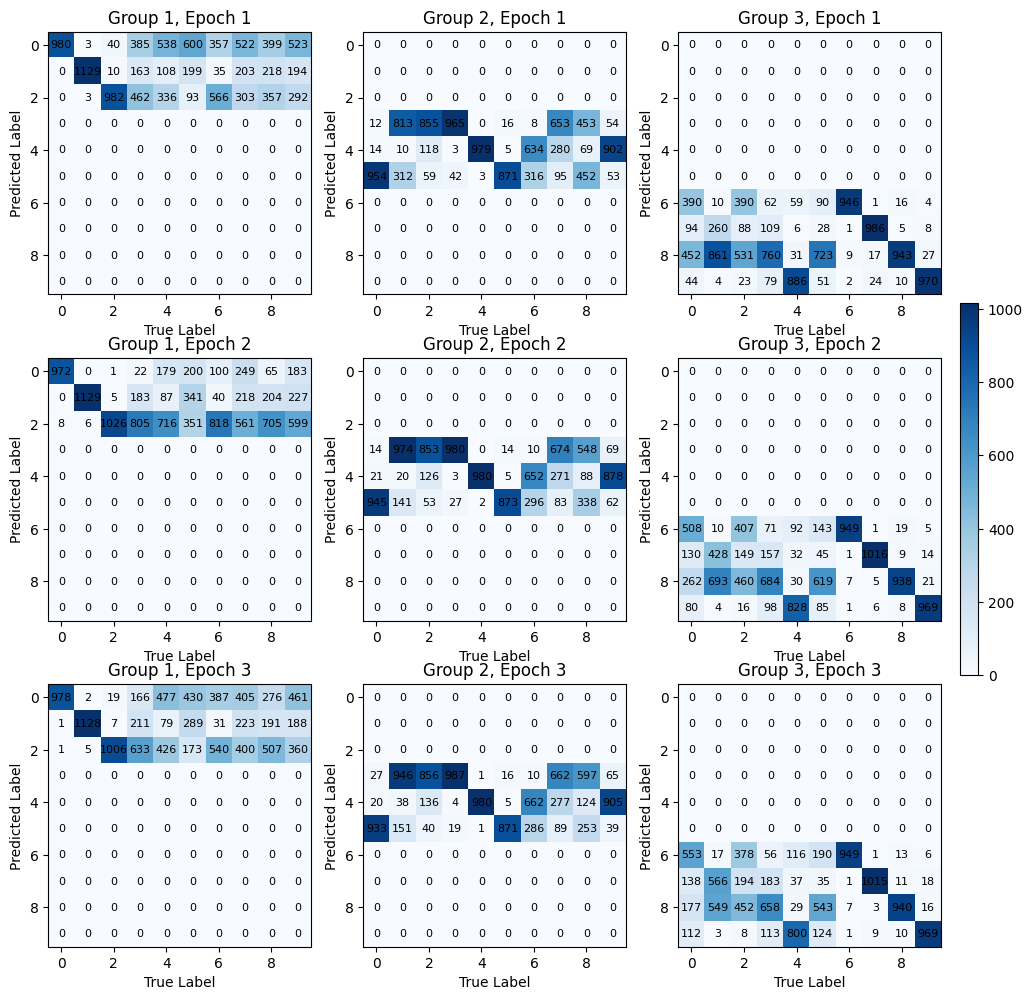

In [114]:
fig, axes = plt.subplots(
    nrows=num_epochs,
    ncols=num_training_groups,
    figsize=(4 * num_training_groups, 4 * num_epochs)
)

# Ensure axes is always 2D
axes = np.array(axes).reshape(num_epochs, num_training_groups)

for m in range(num_training_groups):          # columns = data types
    for n in range(num_epochs):     # rows = epochs

        ax = axes[n, m]
        cm = confusion_matrix_set_set[m][n]

        im = ax.imshow(cm, cmap='Blues')

        # annotate cells
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j, i,
                    str(int(cm[i, j])),
                    ha='center',
                    va='center',
                    color='black',
                    fontsize=8
                )

        ax.set_title(f"Group {m+1}, Epoch {n+1}")

        ax.set_xlabel("True Label")
        ax.set_ylabel("Predicted Label")

# One shared colorbar (important)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)

plt.show()

### PCA Analyses of Penultimate Layer

### Learned PCA

In [206]:
learned_PCA_set = {}
learned_embedded_data_set = {}

In [217]:
num_components = 32

for i in range(num_training_groups):

    all_batches = []

    for j in training_digit_groups[i]:

        for inputs, labels in testing_groups[j]:

            hidden_outputs = model_set[i].hidden(inputs)

            all_batches.append(hidden_outputs.detach().numpy())

    data = np.concatenate(all_batches, axis = 0)

    standardizer = StandardScaler()
    standardized_data = standardizer.fit_transform(data)
    
    pca = PCA(n_components = num_components)
    embedded_data = pca.fit_transform(standardized_data)

    learned_PCA_set[i] = pca
    learned_embedded_data_set[i] = embedded_data

In [218]:
print(inputs.shape, labels.shape, outputs.shape, hidden_outputs.shape, data.shape, embedded_data.shape, pca.components_.shape)

torch.Size([49, 1, 28, 28]) torch.Size([49]) torch.Size([49, 10]) torch.Size([49, 64]) (3969, 64) (3969, 32) (32, 64)


In [208]:
num_digit_groups = len(training_digit_groups)

X = []

for group in training_digit_groups:

    X_i = [0]

    for digit in group:

        num_digit_images = num_testing_images[digit]

        X_i.append(num_digit_images)

    X.append(X_i)
        
digit_indices = [np.cumsum(X_i) for X_i in X]

In [209]:
print(digit_indices)

[array([   0,  980, 2115, 3147]), array([   0, 1010, 1992, 2884]), array([   0,  958, 1986, 2960, 3969])]


(3147, 32)
(2884, 32)
(3969, 32)


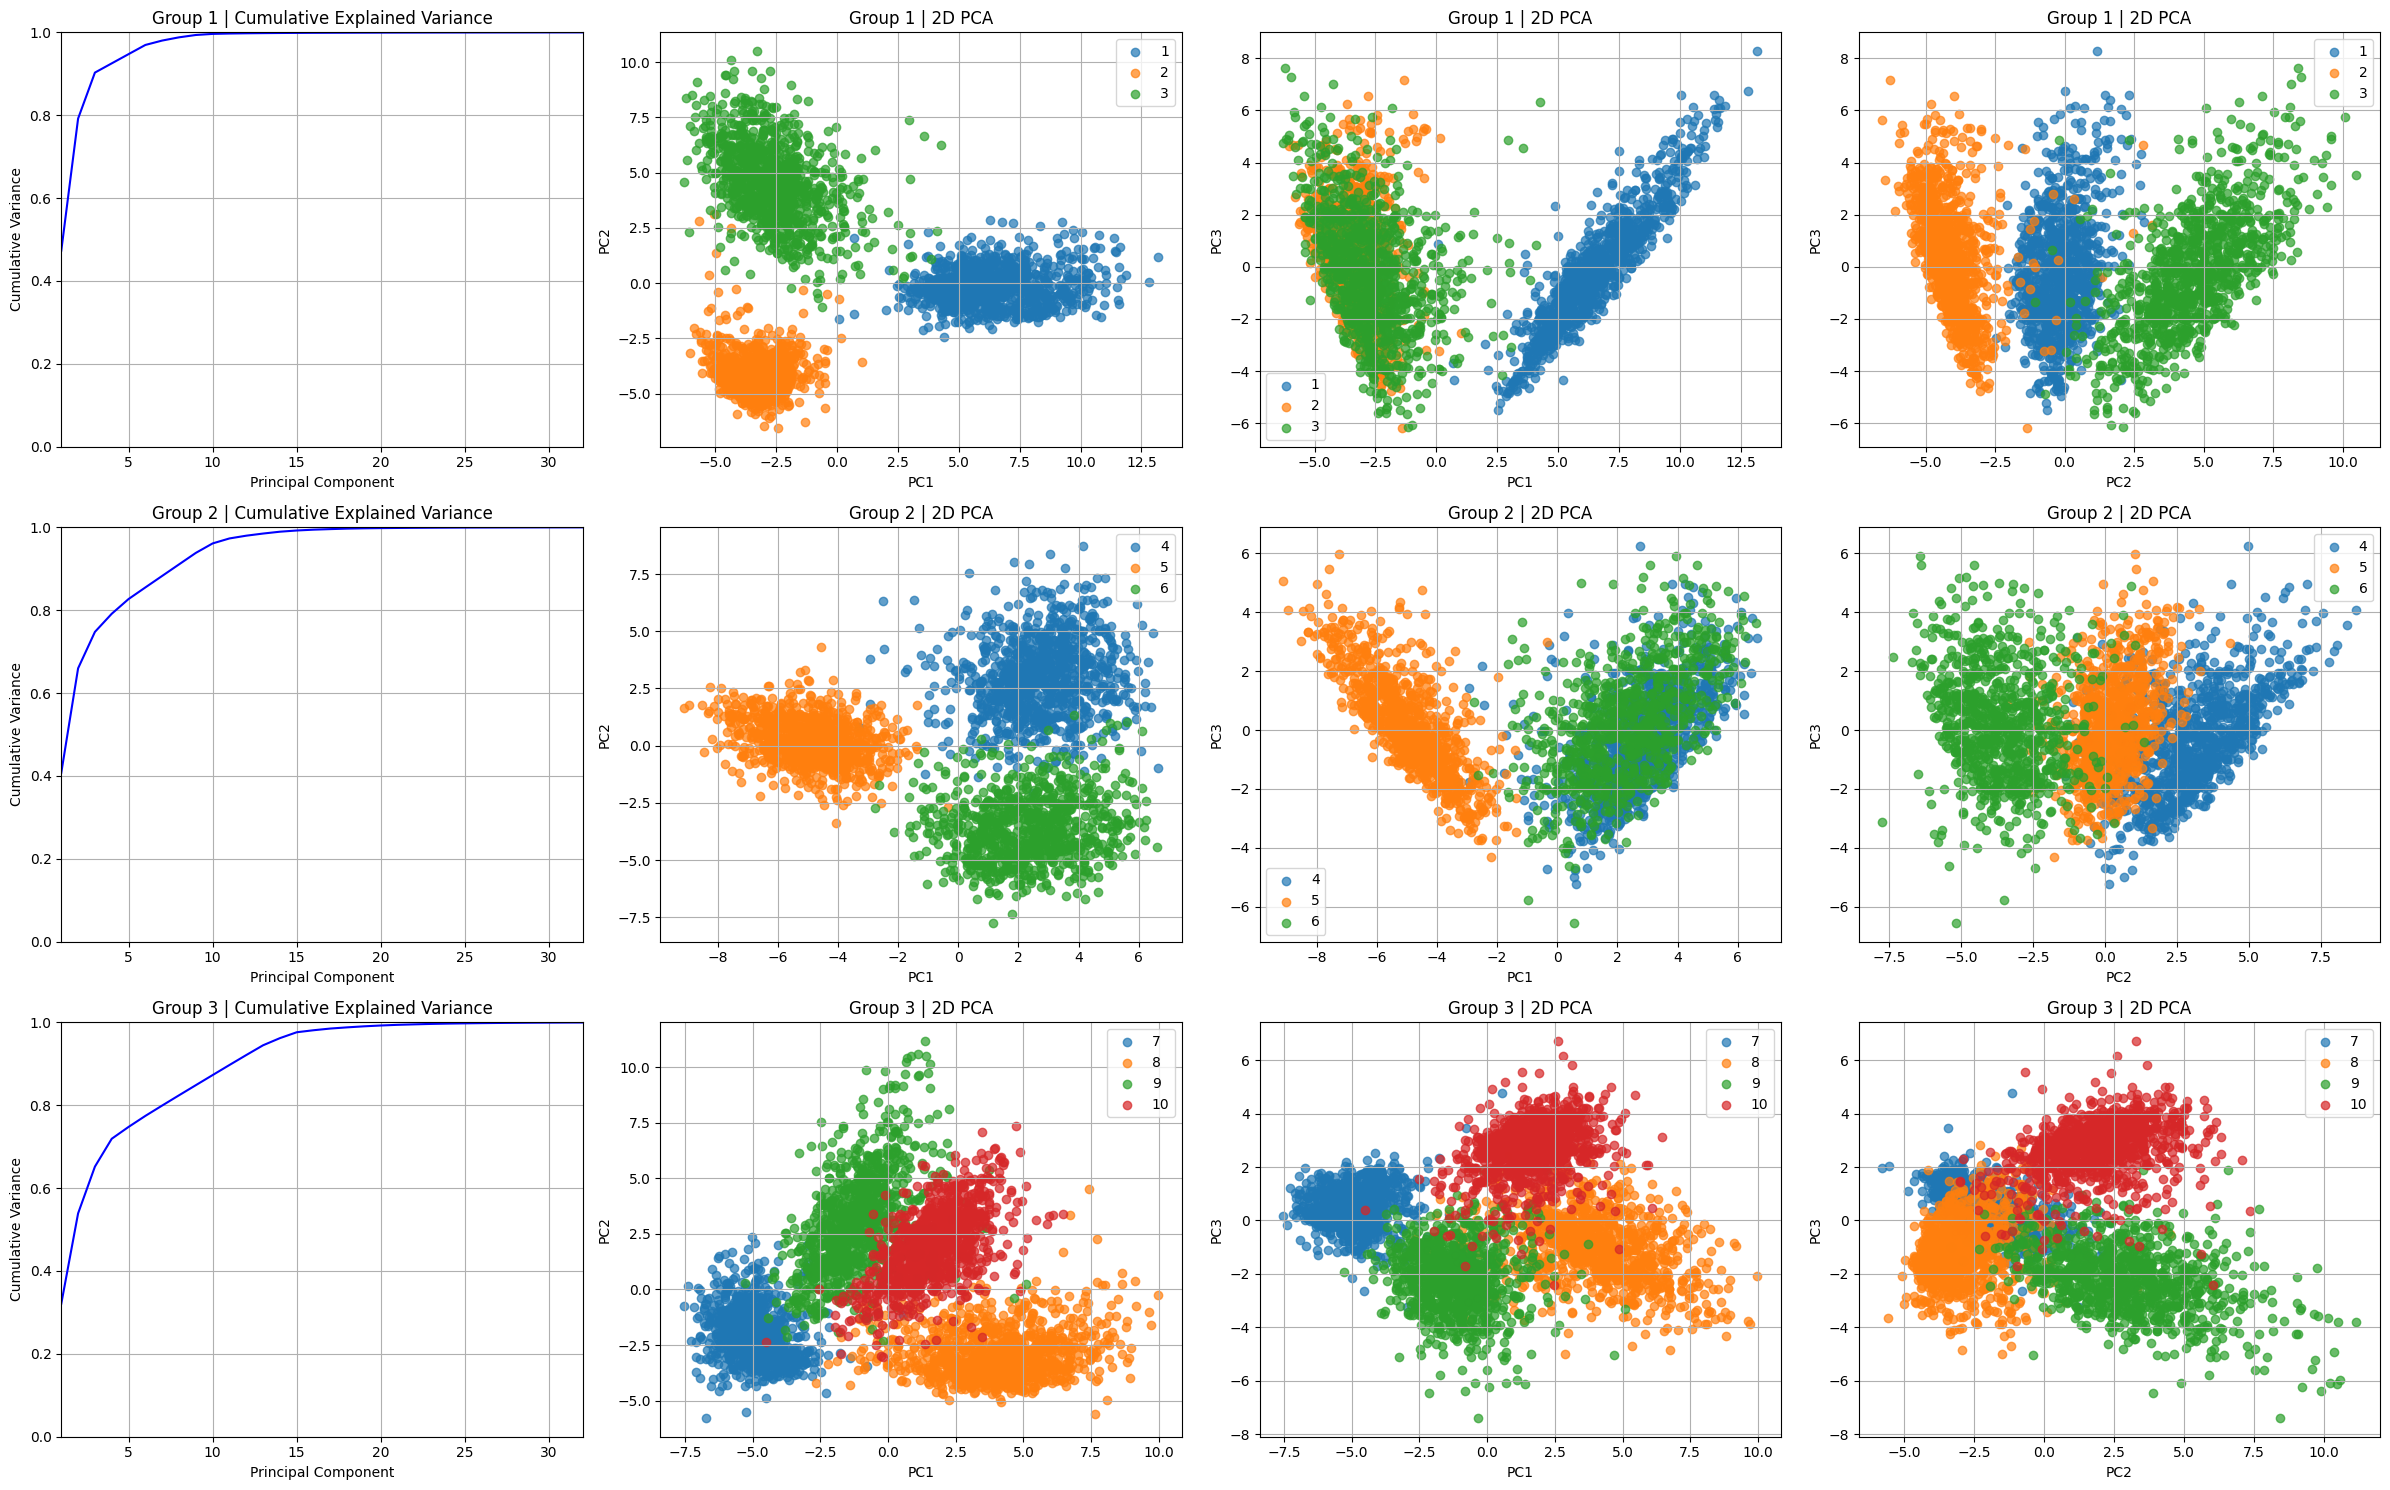

In [219]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots

fig = plt.figure(figsize=(24, 5 * num_training_groups))  # tall figure for 10 rows

for i in range(num_training_groups):

    pca = learned_PCA_set[i]
    embedded_data = learned_embedded_data_set[i]

    print(embedded_data.shape)

    #################################################################
    # Subplot 1: Cumulative Explained Variance
    #################################################################
    ax1 = fig.add_subplot(num_training_groups, 4, i * 4 + 1)

    ax1.plot(
        np.arange(1, len(pca.explained_variance_ratio_) + 1),
        np.cumsum(pca.explained_variance_ratio_),
        color="Blue"
    )

    ax1.set_xlim(1, len(pca.explained_variance_ratio_))
    ax1.set_ylim(0, 1)
    ax1.grid(True)

    ax1.set_title(f"Group {i+1} | Cumulative Explained Variance")
    ax1.set_xlabel("Principal Component")
    ax1.set_ylabel("Cumulative Variance")

    #################################################################
    # Subplot 3: 2D PCA Scatter PCA 1/2
    #################################################################
    ax2 = fig.add_subplot(num_training_groups, 4, i * 4 + 2)

    num_digits = len(digit_indices[i])
    
    for j in range(num_digits-1):
    
        ax2.scatter(
            embedded_data[digit_indices[i][j]:digit_indices[i][j+1], 0],
            embedded_data[digit_indices[i][j]:digit_indices[i][j+1], 1],
            alpha=0.7,
            label=str(training_digit_groups[i][j]+1)
        )


    ax2.set_title(f"Group {i+1} | 2D PCA")
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    ax2.grid(True)
    ax2.legend()

    #################################################################
    # Subplot 3: 2D PCA Scatter PCA 1/3
    #################################################################
    ax3 = fig.add_subplot(num_training_groups, 4, i * 4 + 3)

    num_digits = len(digit_indices[i])
    
    for j in range(num_digits-1):
    
        ax3.scatter(
            embedded_data[digit_indices[i][j]:digit_indices[i][j+1], 0],
            embedded_data[digit_indices[i][j]:digit_indices[i][j+1], 2],
            alpha=0.7,
            label=str(training_digit_groups[i][j]+1)
        )


    ax3.set_title(f"Group {i+1} | 2D PCA")
    ax3.set_xlabel("PC1")
    ax3.set_ylabel("PC3")
    ax3.grid(True)
    ax3.legend()

    #################################################################
    # Subplot 4: 2D PCA Scatter PCA 2/3
    #################################################################
    ax4 = fig.add_subplot(num_training_groups, 4, i * 4 + 4)

    num_digits = len(digit_indices[i])
    
    for j in range(num_digits-1):
    
        ax4.scatter(
            embedded_data[digit_indices[i][j]:digit_indices[i][j+1], 1],
            embedded_data[digit_indices[i][j]:digit_indices[i][j+1], 2],
            alpha=0.7,
            label=str(training_digit_groups[i][j]+1)
        )


    ax4.set_title(f"Group {i+1} | 2D PCA")
    ax4.set_xlabel("PC2")
    ax4.set_ylabel("PC3")
    ax4.grid(True)
    ax4.legend()

# final layout
plt.tight_layout()
plt.show()

### Remembered PCA

In [222]:
remembered_embedded_data_set = {group: {} for group in range(num_training_groups)}

In [223]:
num_components = 64

for i in range(num_training_groups):

    for j in range(num_testing_groups):

        all_batches = []

        for inputs, labels in testing_groups[j]:

            hidden_outputs = model_set[i].hidden(inputs)

            all_batches.append(hidden_outputs.detach().numpy())

        data = np.concatenate(all_batches, axis = 0)

        standardizer = StandardScaler()
        standardized_data = standardizer.fit_transform(data)
    
        projected_data = np.matmul(standardized_data, np.transpose(learned_PCA_set[i].components_))

        remembered_embedded_data_set[i][j] = projected_data

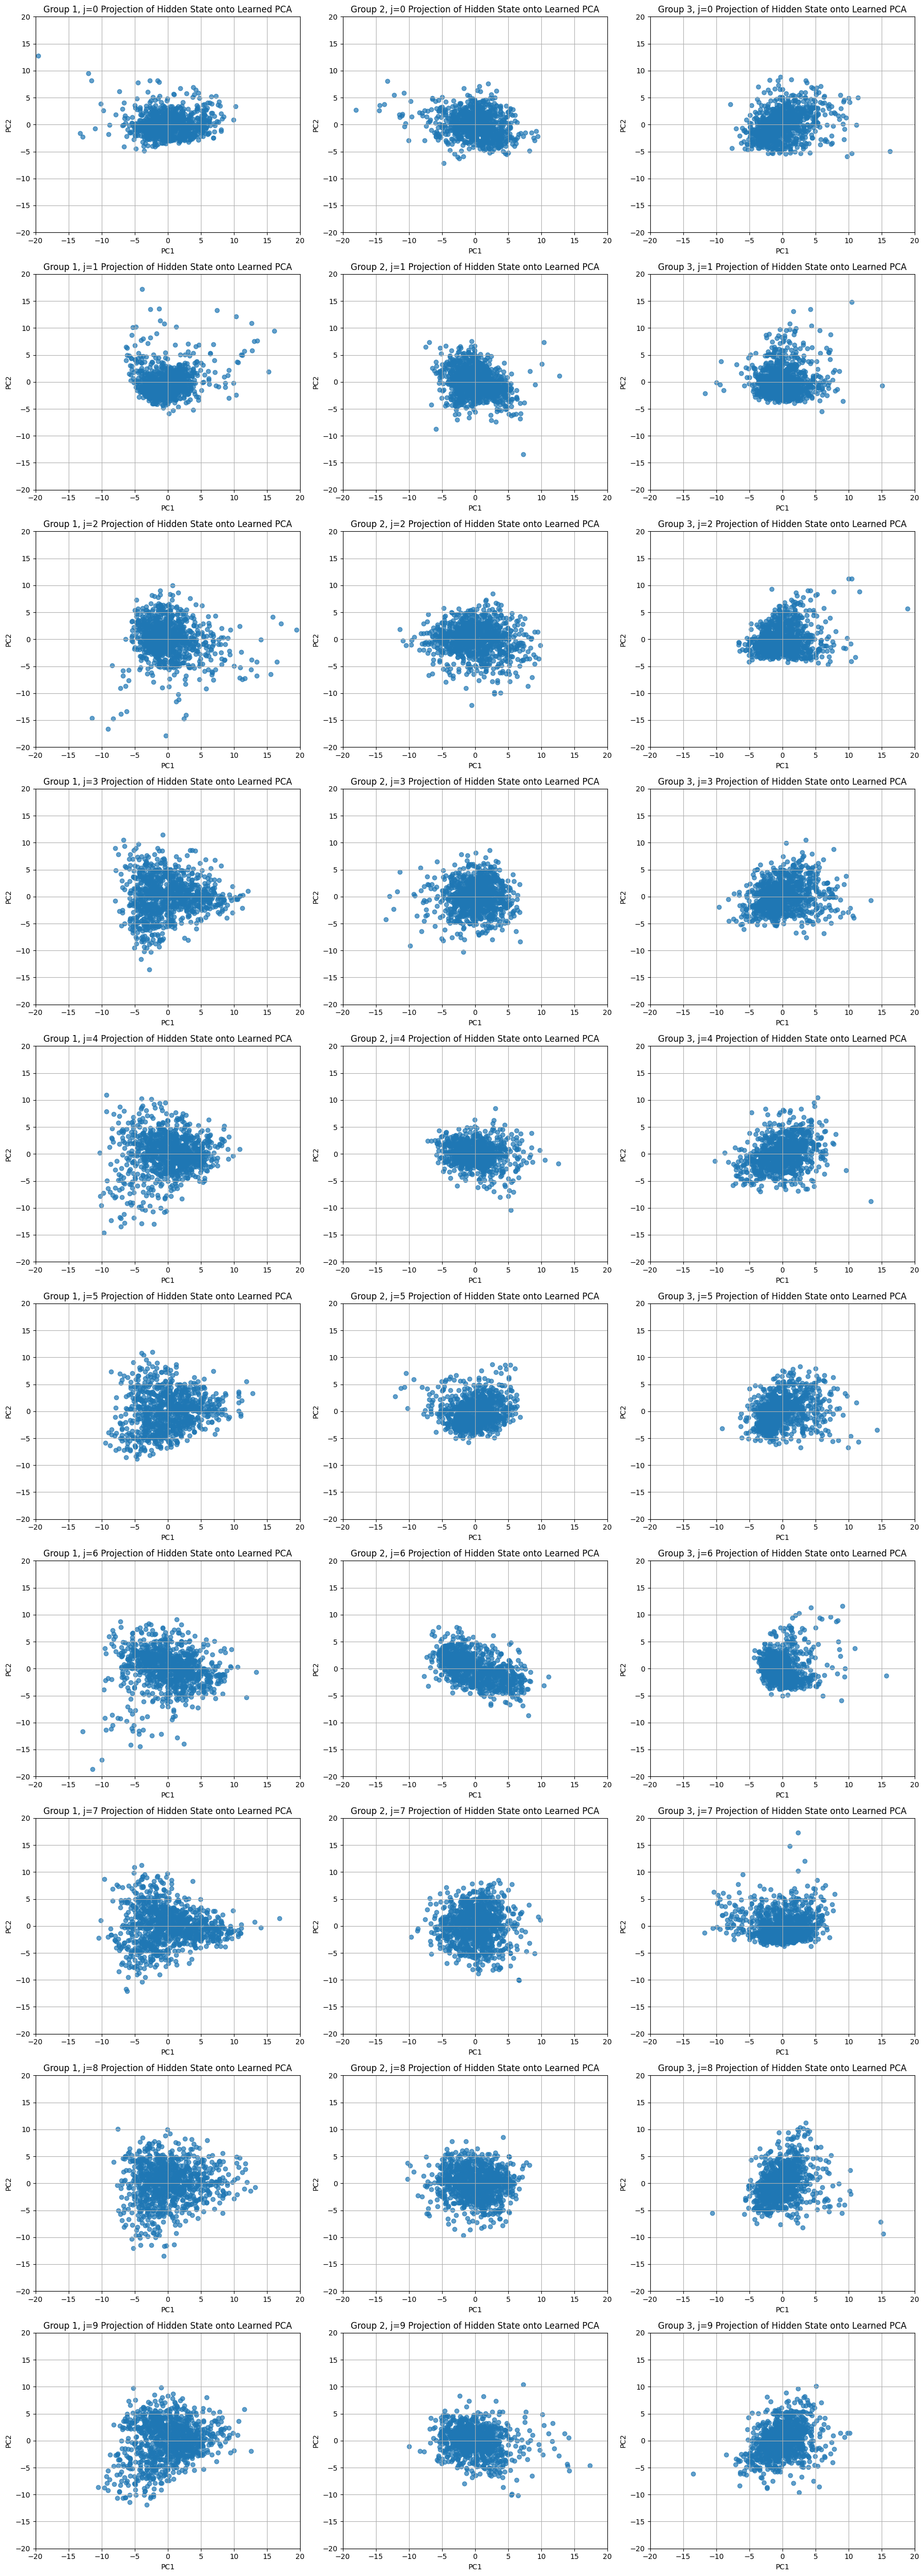

In [226]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots

fig = plt.figure(figsize=(18, 5 * 10))  # tall figure for 10 rows

for j in range(num_training_groups):

    for i in range(num_testing_groups):

        #################################################################
        # Subplot 3: 2D PCA Scatter
        #################################################################
        ax3 = fig.add_subplot(10, 3, i * 3 + j + 1)

        embedded_data = remembered_embedded_data_set[j][i]

        ax3.scatter(
            embedded_data[:, 0],
            embedded_data[:, 1],
            alpha=0.7,
            label = f"Group {j+1}"
        )

        ax3.set_title(f"Group {j+1}, j={i} Projection of Hidden State onto Learned PCA")
        ax3.set_xlabel("PC1")
        ax3.set_ylabel("PC2")
        ax3.grid(True)
        ax3.set_xlim(-20, 20)
        ax3.set_ylim(-20, 20)

# final layout
plt.tight_layout()
plt.show()

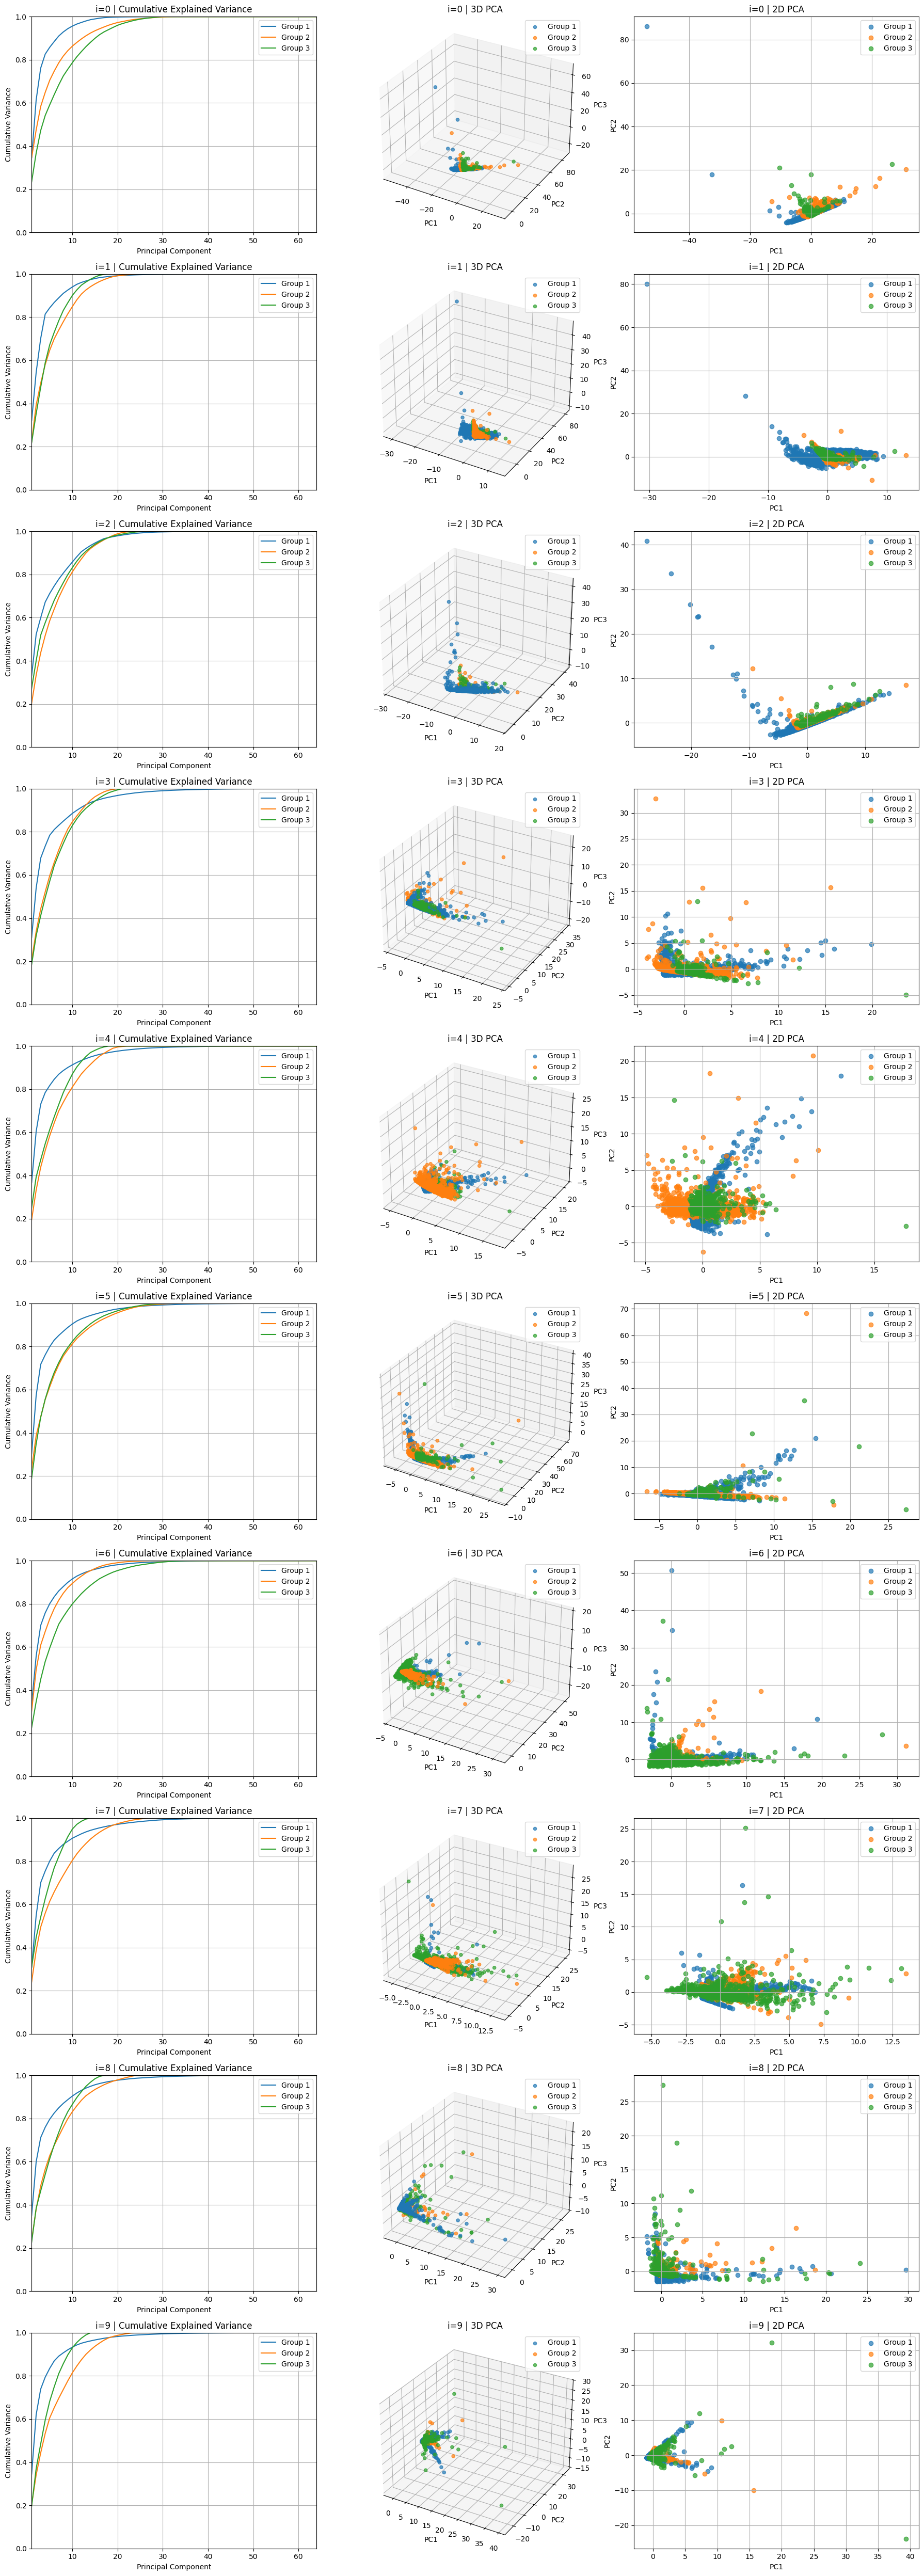

In [88]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots

fig = plt.figure(figsize=(18, 5 * 10))  # tall figure for 10 rows

for i in range(10):

    #################################################################
    # Subplot 1: Cumulative Explained Variance
    #################################################################
    ax1 = fig.add_subplot(10, 3, i * 3 + 1)

    for j in range(num_groups):

        pca = remembered_PCA_set[j][i]
        
        ax1.plot(
            np.arange(1, len(pca.explained_variance_ratio_) + 1),
            np.cumsum(pca.explained_variance_ratio_),
            label = f"Group {j+1}"
        )

    ax1.set_xlim(1, len(pca.explained_variance_ratio_))
    ax1.set_ylim(0, 1)
    ax1.grid(True)
    ax1.legend()

    ax1.set_title(f"i={i} | Cumulative Explained Variance")
    ax1.set_xlabel("Principal Component")
    ax1.set_ylabel("Cumulative Variance")

    #################################################################
    # Subplot 2: 3D PCA Scatter
    #################################################################
    ax2 = fig.add_subplot(10, 3, i * 3 + 2, projection='3d')

    for j in range(num_groups):

        embedded_data = remembered_embedded_data_set[j][i]

        ax2.scatter(
            embedded_data[:, 0],
            embedded_data[:, 1],
            embedded_data[:, 2],
            alpha=0.7,
            label = f"Group {j+1}"
        )

    ax2.set_title(f"i={i} | 3D PCA")
    ax2.legend()
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    ax2.set_zlabel("PC3")

    #################################################################
    # Subplot 3: 2D PCA Scatter
    #################################################################
    ax3 = fig.add_subplot(10, 3, i * 3 + 3)

    for j in range(3):

        embedded_data = remembered_embedded_data_set[j][i]

        ax3.scatter(
            embedded_data[:, 0],
            embedded_data[:, 1],
            alpha=0.7,
            label = f"Group {j+1}"
        )

    ax3.set_title(f"i={i} | 2D PCA")
    ax3.legend()
    ax3.set_xlabel("PC1")
    ax3.set_ylabel("PC2")
    ax3.grid(True)

# final layout
plt.tight_layout()
plt.show()

In [83]:
print(hidden_outputs.shape, data.shape)

torch.Size([1, 64]) (1009, 64)
